/tmp/ipykernel_5759/1846103997.py:64: RuntimeWarning: invalid value encountered in divide
  corrected_image = (image - dark_field) / flood_field
/tmp/ipykernel_5759/1846103997.py:64: RuntimeWarning: divide by zero encountered in divide
  corrected_image = (image - dark_field) / flood_field


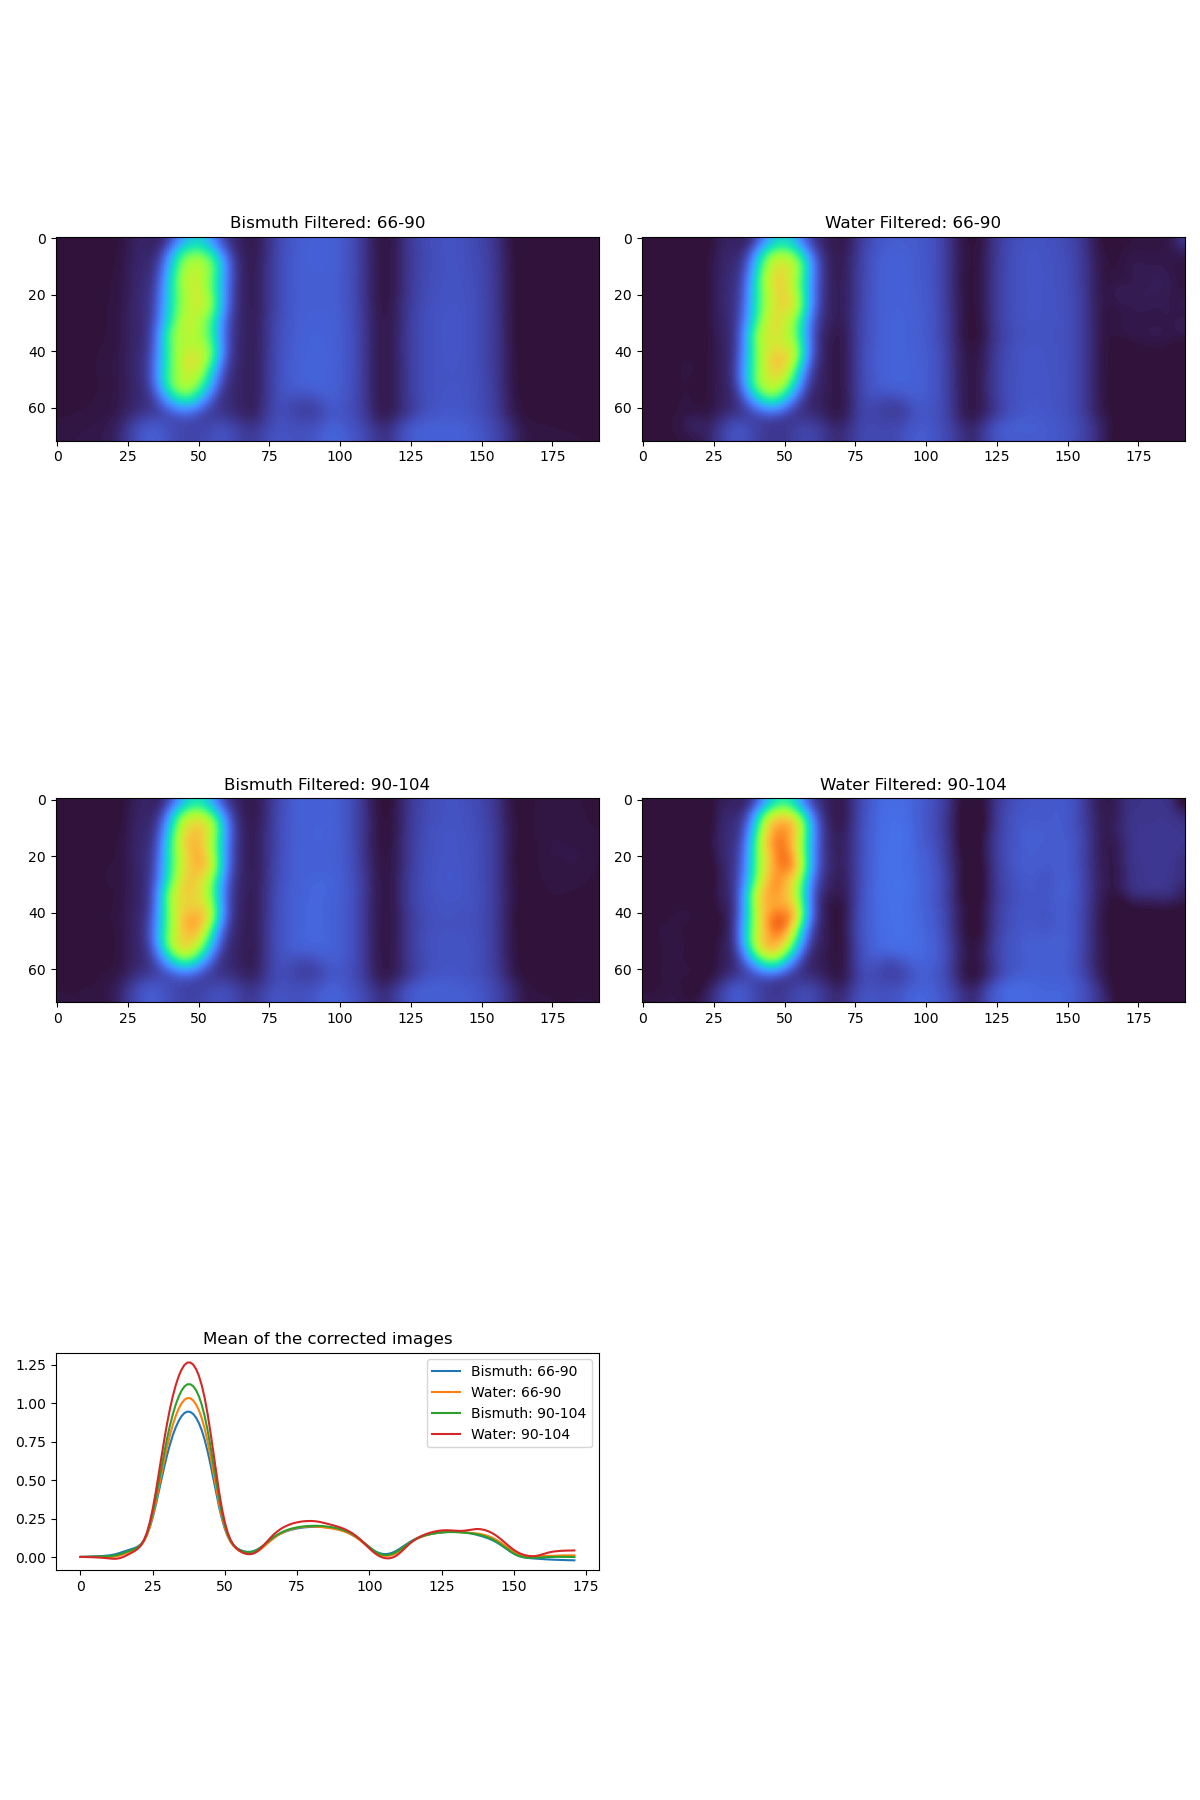

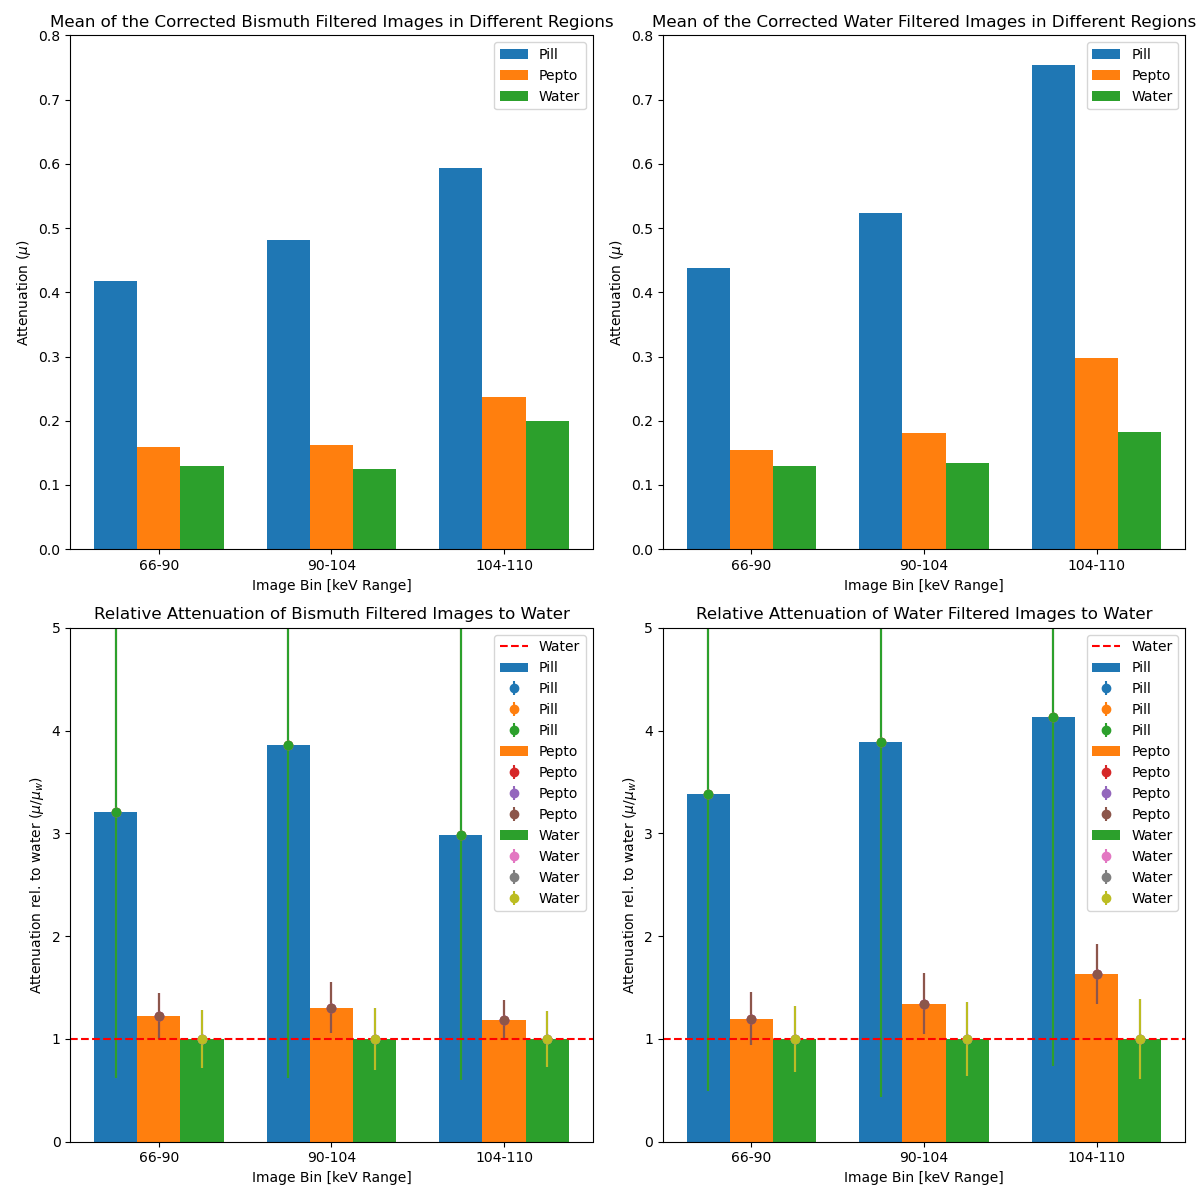

In [79]:
# %%
# Looking at the pepto images

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import mpl_interactions as pli

# Define the root directory to start the search
root_dir = './'

# Load .npy files
data_list, data_names = [], []
for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file.endswith('.npy'):
            file_path = os.path.join(subdir, file)
            data_list.append(np.load(file_path))
            data_names.append(file_path)

# Sort data names and data list
data_list = [x for _, x in sorted(zip(data_names, data_list))]
data_names = sorted(data_names)
data_list = np.array(data_list)

# %%
# Define image groups
two_views = data_list.squeeze()[:7]
darks = data_list.squeeze()[7:14]
inverted = data_list.squeeze()[14:21]
floods = data_list.squeeze()[21:28]
bismuth_filtered = data_list.squeeze()[28:35]
water_filtered = data_list.squeeze()[35:42]
Original_test = data_list.squeeze()[42:49]

# %%
# Function to detect and correct pixels
def detect_and_correct_pixels(image, lower_threshold, upper_threshold):
    corrected_image = image.copy()
    underresponding_mask = image < lower_threshold
    overresponding_mask = image > upper_threshold

    def mean_of_neighbors(img, x, y):
        neighbors = [img[i, j] for i in range(max(0, x-1), min(img.shape[0], x+2))
                     for j in range(max(0, y-1), min(img.shape[1], y+2)) if (i, j) != (x, y)]
        return np.mean(neighbors)

    for x, y in np.argwhere(underresponding_mask):
        corrected_image[x, y] = mean_of_neighbors(image, x, y)
    for x, y in np.argwhere(overresponding_mask):
        corrected_image[x, y] = mean_of_neighbors(image, x, y)

    return corrected_image

# Function to correct images
def correct_images(images, darks, floods):
    corrected_images = []
    for i in range(6):
        dark_field, flood_field, image = darks[i], floods[i], images[i].copy()
        flood_field -= dark_field
        flood_field = flood_field / np.mean(flood_field[:15, 20:-20]) * np.mean(image[:15, 20:-20])
        corrected_image = (image - dark_field) / flood_field
        corrected_image = np.clip(corrected_image, 0.1, 2)
        corrected_image[np.isnan(corrected_image)] = 0.1

        mean, std = np.mean(corrected_image), np.std(corrected_image)
        lower_threshold, upper_threshold = mean - std, mean + std
        corrected_image = detect_and_correct_pixels(corrected_image, lower_threshold, upper_threshold)
        corrected_images.append(-np.log(corrected_image))

    return [gaussian_filter(image, 3) for image in corrected_images]

# Correct the bismuth_filtered and water_filtered images
corrected_bismuth = correct_images(bismuth_filtered, darks, floods)
corrected_water = correct_images(water_filtered, darks, floods)

# %%
# Plot the median of the corrected images
bins = np.array([20, 30, 76, 100, 114, 120]) - 10
names = [f'{bins[i]}-{bins[i+1]}' for i in range(len(bins)-1)]

# Create a figure with subplots
fig, axs = plt.subplots(3, 2, figsize=(12, 18))

# Plot Bismuth Filtered images
for i in range(2, 4):
    ax = axs[i-2, 0]
    ax.set_title(f'Bismuth Filtered: {names[i]}')
    im = ax.imshow(np.rot90(corrected_bismuth[i]), cmap='turbo', vmin=0., vmax=1.75)
    # fig.colorbar(im, ax=ax)

# Plot Water Filtered images
for i in range(2, 4):
    ax = axs[i-2, 1]
    ax.set_title(f'Water Filtered: {names[i]}')
    im = ax.imshow(np.rot90(corrected_water[i]), cmap='turbo', vmin=0., vmax=1.75)
    # fig.colorbar(im, ax=ax)

# Plot the median of the corrected images along a specific axis
ax = axs[2, 0]
for i in range(2, 4):
    ax.plot(np.mean(corrected_bismuth[i][10:-10, 20:-20], axis=1), label=f'Bismuth: {names[i]}')
    ax.plot(np.mean(corrected_water[i][10:-10, 20:-20], axis=1), label=f'Water: {names[i]}')
ax.set_aspect(20 * (corrected_bismuth[2].shape[0] / corrected_bismuth[2].shape[1]), adjustable='box')
ax.legend()
ax.set_title('Mean of the corrected images')

# Hide the empty subplot
axs[2, 1].axis('off')

plt.tight_layout()
plt.show()

# %%
# Bar chart of the mean of the regions
regions = [[25, 50], [75, 90], [120, 140]]
region_names = ['Pill', 'Pepto', 'Water']

# Bar chart of mean values for specified regions
def plot_mean_values(corrected_images, title, ax):
    values = []
    for i in range(3):
        region_values = [np.mean(corrected_images[j][regions[i][0]:regions[i][1], 10:-35]) for j in range(2, 5)]
        values.append(region_values)

    values = np.array(values)
    x = np.arange(2, 5)
    width = 0.25

    for i in range(3):
        ax.bar(x + i * width, values[i], width, label=region_names[i])
    ax.set_xlabel('Image Bin [keV Range]')
    ax.set_ylabel('Attenuation ($\mu$)')
    ax.set_title(title)
    ax.set_ylim(0,0.8)
    ax.set_xticks(x + width)
    ax.set_xticklabels([f'{name}' for name in names[2:5]])
    ax.legend()

# Bar chart of relative attenuation to water
def plot_relative_attenuation(corrected_images, title, ax):
    values = []
    stds = []
    for i in range(3):
        region_values = [np.mean(corrected_images[j][regions[i][0]:regions[i][1], 10:-35]) / np.mean(corrected_images[j][regions[2][0]:regions[2][1], 10:-35]) for j in range(2, 5)]
        region_std = [np.std(corrected_images[j][regions[i][0]:regions[i][1], 10:-35]) / np.mean(corrected_images[j][regions[2][0]:regions[2][1], 10:-35]) for j in range(2, 5)]
        values.append(region_values)
        stds.append(region_std)

    values = np.array(values)
    x = np.arange(2, 5)
    width = 0.25

    
    for i in range(3):
        ax.bar(x + i * width, values[i], width, label=region_names[i])
        for j in range(3):
            ax.errorbar(x + i * width, values[i], yerr=stds[i], fmt='o', label=region_names[i
            ])
    ax.set_xlabel('Image Bin [keV Range]')
    ax.set_ylabel('Attenuation rel. to water ($\mu/\mu_w$)')
    ax.set_title(title)
    ax.set_ylim(0,5)
    ax.set_xticks(x + width)
    ax.set_xticklabels([f'{name}' for name in names[2:5]])
    ax.axhline(1, color='red', linestyle='--', label='Water')
    ax.legend()

# Create a figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

# Plot mean values
plot_mean_values(corrected_bismuth, 'Mean of the Corrected Bismuth Filtered Images in Different Regions', axs[0, 0])
plot_mean_values(corrected_water, 'Mean of the Corrected Water Filtered Images in Different Regions', axs[0, 1])

# Plot relative attenuation
plot_relative_attenuation(corrected_bismuth, 'Relative Attenuation of Bismuth Filtered Images to Water', axs[1, 0])
plot_relative_attenuation(corrected_water, 'Relative Attenuation of Water Filtered Images to Water', axs[1, 1])

plt.tight_layout()
plt.show()

In [61]:
# What would be the metric that seperates the signal best between water and bismuth?

# Maximize the contrast to noise ratio (CNR) between the two materials

region_w = alpha * im1 + beta * im2 + gamma * im3  + alpha2 * im4 + beta2 * im5 + gamma2 * im6
region_b = alpha3 * im1 + beta3 * im2 + gamma3 * im3  + alpha4 * im4 + beta4 * im5 + gamma4 * im6

mu_w = np.mean(region_w)
mu_b = np.mean(region_b)
sigma_w = np.std(region_w)
sigma_b = np.std(region_b)

CNR = np.abs(mu_b - mu_w) / (sigma_b**2 + sigma_w**2)**0.5


NameError: name 'alpha' is not defined

In [62]:
import numpy as np
from scipy.optimize import minimize

def calculate_cnr(weights, ims_bismuth, ims_water):
    alpha, beta, gamma, alpha2, beta2, gamma2 = weights
    
    region_b = alpha * ims_bismuth[0] + beta * ims_bismuth[1] + gamma * ims_bismuth[2] + alpha2 * ims_bismuth[3] + beta2 * ims_bismuth[4] + gamma2 * ims_bismuth[5]
    # Want this to have high contrast
    region_w = alpha * ims_water[0] + beta * ims_water[1] + gamma * ims_water[2] + alpha2 * ims_water[3] + beta2 * ims_water[4] + gamma2 * ims_water[5]
    # Want this to have low signal
    # Minimize signal to noise ratio in the water region
    
    mu_w = np.mean(region_w)
    mu_b = np.mean(region_b)
    sigma_w = np.std(region_w)
    sigma_b = np.std(region_b)
    
    cnr = np.abs(mu_b - mu_w) / np.sqrt(sigma_b**2 + sigma_w**2)
    snr = np.abs(mu_w) / sigma_w
    return -cnr + snr  # Negative CNR for minimization

def optimize_cnr(ims_bismuth, ims_water):
    initial_weights = [1,1,1,-1,-1,1]  # Initial weights for the optimization
    bounds = [(-4, 4)] * 6  # Bounds for the weights (assuming they are between 0 and 1)
    
    result = minimize(calculate_cnr, initial_weights, args=(ims_bismuth, ims_water), bounds=bounds, method='Nelder-Mead')
    
    optimized_weights = result.x
    max_cnr = -result.fun  # Convert back to positive CNR
    
    return optimized_weights, max_cnr

regions = [[25, 50], [75, 90], [120, 140]]
region_names = ['Pill', 'Pepto', 'Water']

a, b = 95, 105
c,d = 20,-20
# Example usage with synthetic data
im1 = corrected_water[2][a:b,c:d]
im2 = corrected_water[3][a:b,c:d]
im3 = corrected_water[4][a:b,c:d]
im4 = corrected_bismuth[2][a:b,c:d]
im5 = corrected_bismuth[3][a:b,c:d]
im6 = corrected_bismuth[4][a:b,c:d]

ims_bismuth = [im1, im2, im3, im4, im5, im6]

e, f = 100, 180
g,h = 20,-20

im1_w = corrected_water[2][e:f,g:h]
im2_w = corrected_water[3][e:f,g:h]
im3_w = corrected_water[4][e:f,g:h]
im4_w = corrected_bismuth[2][e:f,g:h]
im5_w = corrected_bismuth[3][e:f,g:h]
im6_w = corrected_bismuth[4][e:f,g:h]

ims_water = [im1_w, im2_w, im3_w, im4_w, im5_w, im6_w]

optimized_weights, max_cnr = optimize_cnr(ims_bismuth, ims_water)
print("Optimized Weights:", optimized_weights)
print("Maximized CNR:", max_cnr)


Optimized Weights: [ 4.          4.         -4.          2.21149578  4.         -3.99995959]
Maximized CNR: 0.6345223529881763


Text(0.5, 1.0, 'Bismuth Region')

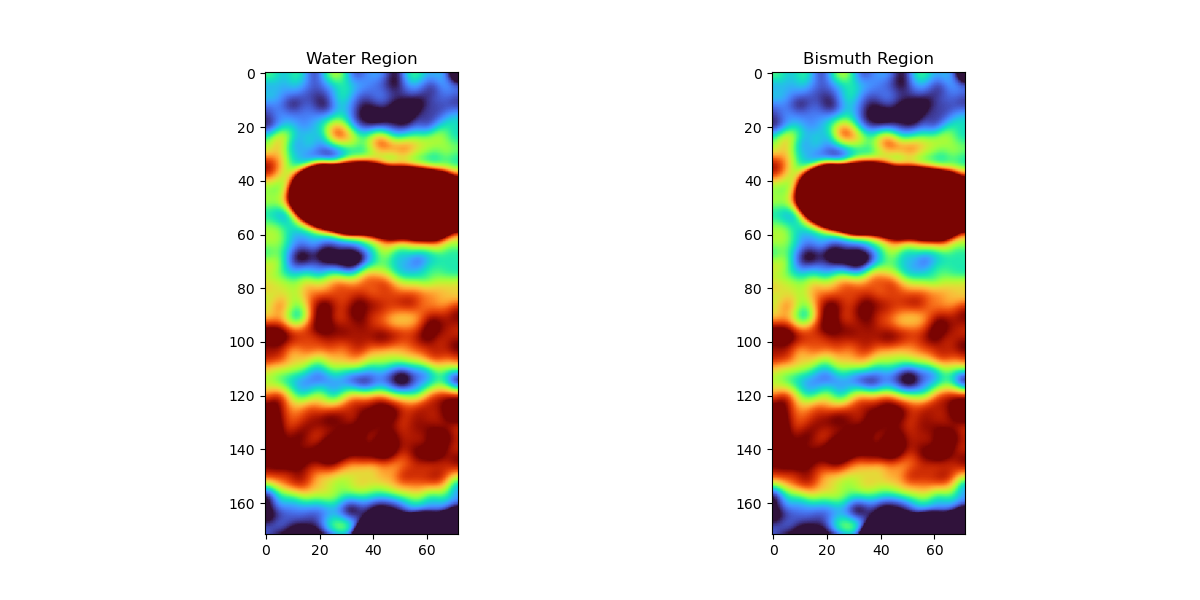

In [63]:

# plot the image with the optimized weights
region_w = optimized_weights[0] * corrected_water[2] + optimized_weights[1] * corrected_water[3] + optimized_weights[2] * corrected_water[4] + optimized_weights[3] * corrected_bismuth[2] + optimized_weights[4] * corrected_bismuth[3] + optimized_weights[5] * corrected_bismuth[4]
region_b = optimized_weights[0] * corrected_water[2] + optimized_weights[1] * corrected_water[3] + optimized_weights[2] * corrected_water[4] + optimized_weights[3] * corrected_bismuth[2] + optimized_weights[4] * corrected_bismuth[3] + optimized_weights[5] * corrected_bismuth[4]

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(region_w[:-20], cmap='turbo', vmin=np.percentile(region_w[:-20], 5), vmax=np.percentile(region_w[:-20], 80))
axs[0].set_title('Water Region')
axs[1].imshow(region_b[:-20], cmap='turbo', vmin=np.percentile(region_b[:-20], 5), vmax=np.percentile(region_b[:-20], 80))   
axs[1].set_title('Bismuth Region')

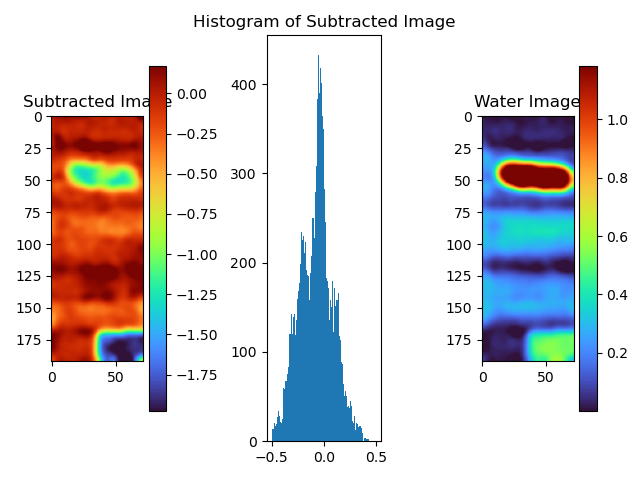

In [64]:
plt.figure()

corrected_bismuth[3] = corrected_bismuth[2]/ np.mean(corrected_bismuth[2][130:140,20:-20])
corrected_water[3] = corrected_water[3]/ np.mean(corrected_water[3][130:140,20:-20])
subtracted = (corrected_bismuth[4] - corrected_water[4])/np.mean(corrected_water[4])
plt.subplot(131)
plt.imshow(subtracted, cmap='turbo', vmin=np.percentile(subtracted, 1), vmax=np.percentile(subtracted, 95))
plt.title('Subtracted Image')
plt.colorbar()
plt.subplot(132)
plt.hist(subtracted.flatten(), bins=100, range=(-0.5, 0.5))
plt.title('Histogram of Subtracted Image')  
plt.subplot(133)
plt.imshow(corrected_water[4], cmap='turbo', vmin=np.percentile(corrected_water[4], 5), vmax=np.percentile(corrected_water[4], 95))
plt.title('Water Image')
plt.colorbar()
plt.tight_layout()
plt.show()

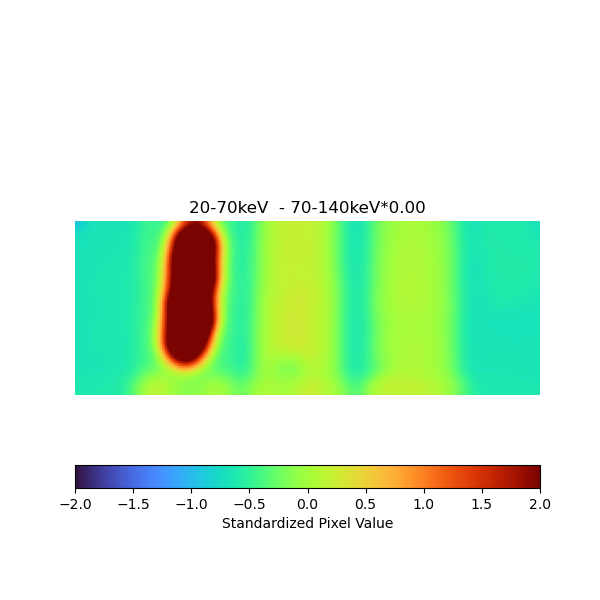

In [101]:
import mpl_interactions.ipyplot as iplt

# im1 = im1 - im1.min()
# im1 = im1 / im1.max()

# im2 = im2 - im2.min()
# im2 = im2 / im2.max()

im_low = corrected_bismuth[3]
im_hi = corrected_water[4]

def f(param1):
    temp_im = (im_low- im_hi* param1 )
    # define a standard scaler function
    def standard_scaler(x):
        return (x - x.mean()) / x.std()
    return np.rot90(standard_scaler(temp_im))

fig, ax = plt.subplots(figsize=(6,6))
controls = iplt.imshow(f, param1=(0.,2),vmin_vmax=("r", -2, 2),cmap='turbo')
plt.axis('off')
plt.colorbar(orientation='horizontal',label='Standardized Pixel Value')


with controls:
    # directly using string formatting
    # the formatting is performed in the update
    iplt.title(title="20-70keV  - 70-140keV*{param1:.2f}")
